1.   토큰 소비와 실행 시간 감소: ReWOO는 단일 실행으로 도구 사용 체인을 완전하게 생성하여 토큰 소비와 실행 시간을 줄입니다. ReACT 스타일 에이전트 아키텍처는 각 추론 단계에서 시스템 프롬프트와 이전 단계를 매번 LLM에 제공하기 때문에 많은 LLM 호출과 중복 프리픽스를 필요로 합니다.
2.   파인 튜닝 과정 간소화: ReWOO는 플래닝 데이터가 도구 출력에 의존하지 않기 때문에, 이론적으로 도구를 실제로 호출하지 않고도 모델을 파인 튜닝할 수 있습니다.

In [14]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community chromadb


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
from uuid import uuid4

In [27]:
unique_id = uuid4().hex[0:8]
os.environ['LANNGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'Reasoning without Observation - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ''
os.environ['OPENAI_API_KEY'] = ''
os.environ['TAVILY_API_KEY'] = ''

In [17]:
unique_id

'ed34acfc'

Define graph state

In [18]:
from typing import List
from typing_extensions import TypedDict

In [19]:
class ReWoo(TypedDict):
    task: str
    plan_string : str
    steps: List
    results: dict
    result : str

Planner

In [20]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o')

In [21]:
prompt = """For the following task, make plans that can solve the problem step by step. For each plan, indicate \
which external tool together with tool input to retrieve evidence. You can store the evidence into a \
variable #E that can be called by later tools. (Plan, #E1, Plan, #E2, Plan, ...)

Tools can be one of the following:
(1) Google[input]: Worker that searches results from Google. Useful when you need to find short
and succinct answers about a specific topic. The input should be a search query.
(2) LLM[input]: A pretrained LLM like yourself. Useful when you need to act with general
world knowledge and common sense. Prioritize it when you are confident in solving the problem
yourself. Input can be any instruction.

For example,
Task: Thomas, Toby, and Rebecca worked a total of 157 hours in one week. Thomas worked x
hours. Toby worked 10 hours less than twice what Thomas worked, and Rebecca worked 8 hours
less than Toby. How many hours did Rebecca work?
Plan: Given Thomas worked x hours, translate the problem into algebraic expressions and solve
with Wolfram Alpha. #E1 = WolframAlpha[Solve x + (2x − 10) + ((2x − 10) − 8) = 157]
Plan: Find out the number of hours Thomas worked. #E2 = LLM[What is x, given #E1]
Plan: Calculate the number of hours Rebecca worked. #E3 = Calculator[(2 ∗ #E2 − 10) − 8]

Begin!
Describe your plans with rich details. Each Plan should be followed by only one #E.

Task: {task}"""

In [22]:
task = '2024년 호주 오픈 남자 단식 우승자의 정확한 고향은 어디인가요?'
result = model.invoke(prompt.format(task= task))
print(result.content)

Plan: First, determine who won the Men's Singles title at the 2024 Australian Open. Use Google to find the latest information on the winner of this event. #E1 = Google["2024 Australian Open Men's Singles winner"]

Plan: Once we know the winner, we need to find detailed information about the winner's birthplace. Use Google to search for the birthplace of the identified winner. #E2 = Google["[Winner's Name] birthplace"]

(Note: Replace "[Winner's Name]" with the actual name obtained from #E1 in your search query.)


Planner node

In [23]:
import re
from langchain_core.prompts import ChatPromptTemplate

In [24]:
regex_pattern = r"Plan:\s*(.+)\s*(#E\d+)\s*=\s*(\w+)\s*\[([^\]]+)\]"
prompt_template = ChatPromptTemplate.from_messages([('user', prompt)])
planner = prompt_template | model

def get_plan(state: ReWoo):
    task = state['task']
    result = planner.invoke({'task': task})
    matches = re.findall(regex_pattern, result.content)
    return {'steps': matches, 'plan_string': result.content}

excutor

In [25]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [28]:
search = TavilySearchResults()

In [29]:
def _get_current_task(state: ReWoo):
    if 'results' not in state or state['results'] is None:
        return 1
    if len(state['results']) == len(state['steps']):
        return None
    else:
        return len(state['results']) + 1
    
def tool_excution(state: ReWoo):
    """Worker node that excutes the tools of a given plan."""
    _step = _get_current_task(state)
    _, step_name, tool, tool_input = state['steps'][_step -1]
    _results = (state['results'] or {}) if 'results' in state else {}
    for k,v in _results.items():
        tool_input = tool_input.replace(k, v)
    if tool =='Google':
        result = search.invoke(tool_input)
    elif tool == 'LLM':
        result = model.invoke(tool_input)
    else:
        raise ValueError
    _results[step_name] = str(result)
    return {'results': _results}

solver

In [31]:
solve_prompt = """Solve the following task or problem. To solve the problem, we have made step-by-step Plan and \
retrieved corresponding Evidence to each Plan. Use them with caution since long evidence might \
contain irrelevant information.

{plan}

Now solve the question or task according to provided Evidence above. Respond with the answer
directly with no extra words.

Task: {task}
Response:"""


def solve(state: ReWoo):
    plan = ""
    for _plan, step_name, tool, tool_input in state["steps"]:
        _results = (state["results"] or {}) if "results" in state else {}
        for k, v in _results.items():
            tool_input = tool_input.replace(k, v)
            step_name = step_name.replace(k, v)
        plan += f"Plan: {_plan}\n{step_name} = {tool}[{tool_input}]"
    prompt = solve_prompt.format(plan=plan, task=state["task"])
    result = model.invoke(prompt)
    return {"result": result.content}

define graph

In [32]:
def _route(state):
    _step = _get_current_task(state)
    if _step is None:
        return 'solve'
    else:
        return 'tool'

In [34]:
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

In [35]:
graph = StateGraph(ReWoo)
graph.add_node('plan', get_plan)
graph.add_node('tool', tool_excution)
graph.add_node('solve', solve)
graph.add_edge('plan', 'tool')
graph.add_edge('solve', END)
graph.add_conditional_edges('tool', _route)
graph.add_edge(START, 'plan')

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

In [36]:
from IPython.display import Image, display

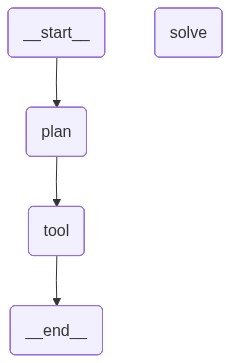

In [37]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [38]:
config = {"configurable": {"thread_id": "1"}}

for s in app.stream({"task": task}, config):
    print(s)
    print("---")

{'plan': {'steps': [("First, identify the winner of the 2024 Australian Open Men's Singles. ", '#E1', 'Google', "2024 Australian Open Men's Singles winner"), ("Find the birthplace or hometown of the 2024 Australian Open Men's Singles winner, using the winner's name obtained in the previous step. ", '#E2', 'Google', 'Birthplace of #E1')], 'plan_string': "Plan: First, identify the winner of the 2024 Australian Open Men's Singles. #E1 = Google[2024 Australian Open Men's Singles winner]\n\nPlan: Find the birthplace or hometown of the 2024 Australian Open Men's Singles winner, using the winner's name obtained in the previous step. #E2 = Google[Birthplace of #E1]\n\nUpon completion of these steps, #E2 will contain the exact information regarding the hometown of the 2024 Australian Open Men's Singles winner."}}
---
{'tool': {'results': {'#E1': '[{\'title\': "2024 Australian Open – Men\'s singles final - Wikipedia", \'url\': \'https://en.wikipedia.org/wiki/2024_Australian_Open_%E2%80%93_Men%27